# 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report
import scipy.sparse as sp

#from google.colab import drive
#drive.mount('/content/drive')

이후 진행할 하이퍼 파라미터 튜닝을 위해 optuna 설치

In [21]:
!pip install optuna

한국어 형태소 분석기인 konlpy 설치

In [22]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 9.1 MB/s eta 0:00:00


In [2]:
# 코랩 한글 폰트 설치 (실행 후 상단 메뉴에서 '런타임' -> '세션 다시 시작' 클릭 필수!)
#for mac
#!apt-get install -y fonts-nanum
#!fc-cache -fv
#!rm -rf ~/.cache/matplotlib

#for window
#!sudo apt-get install -y fonts-nanum
#!sudo fc-cache -fv
#!rm ~/.cache/matplotlib -rf

# 한글 폰트(나눔바른고딕) 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [ ]:
"""
밑에 있는 깃허브 링크에서 raw 파일을 가져오는 식으로 수정했습니다.
# 파일 경로는 실제 저장하신 환경에 맞게 수정해주세요
file_path = '/content/drive/MyDrive/KUGGLE/data/suare_knit_feature_final.csv'
df = pd.read_csv(file_path)

df.info()"""

In [3]:
github_url = 'https://raw.githubusercontent.com/Xerenia/KUGGLE_14th/refs/heads/main/suare_knit_feature_final.csv'

df = pd.read_csv(github_url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3424 entries, 0 to 3423
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   product_id            3424 non-null   int64 
 1   date                  3424 non-null   object
 2   rating                3424 non-null   int64 
 3   is_photo              3424 non-null   int64 
 4   review_text           3424 non-null   object
 5   purchase_option       3424 non-null   object
 6   satisfaction          3424 non-null   object
 7   helpful_indicator     3424 non-null   int64 
 8   is_positive           3424 non-null   int64 
 9   gender                3424 non-null   object
 10  height                3424 non-null   int64 
 11  weight                3424 non-null   int64 
 12  Issue_Pilling         3424 non-null   int64 
 13  Issue_After_Wear      3424 non-null   int64 
 14  Mixed_Sentiment_But   3424 non-null   int64 
 15  Issue_Size            3424 non-null   

# 타겟 변수(정답지) 생성

In [ ]:
# 머신러닝 분류 모델이 예측할 정답지(0 또는 1)를 만들어줍니다.
# 우리의 핵심 목표는 '불만 리뷰(부정)'를 찾아내는 것이므로,
# 평점이 1, 2점인 경우를 1(True)로, 4, 5점인 경우를 0(False)으로 변환합니다.
df['target'] = df['rating'].apply(lambda x: 1 if x <= 2 else 0)

# 데이터 로드 및 타겟 비율 결과 확인
print(f"총 리뷰 개수: {len(df)}건")
print("모델이 학습할 타겟(0: 긍정, 1: 부정)의 불균형 비율 확인")

# value_counts에 normalize=True를 주면 개수 대신 비율(0~1)을 반환합니다.
target_ratio = df['target'].value_counts(normalize=True) * 100
print(target_ratio.round(2).astype(str) + ' %')

총 리뷰 개수: 3424건
모델이 학습할 타겟(0: 긍정, 1: 부정)의 불균형 비율 확인
target
0    82.8 %
1    17.2 %
Name: proportion, dtype: object


코드 상세 분석 (Why & What)
1. 왜 이 코드를 사용했나요? (Why?)

이진 분류(Binary Classification) 셋업: 우리가 수집한 원래 데이터의 정답지는 rating(별점 1, 2, 4, 5점)입니다. 하지만 머신러닝 모델은 이 상태 그대로 학습하기보다, "이 리뷰가 불만(1)인가, 아닌가(0)?"라는 명확한 O/X 퀴즈(0과 1)로 바꿔주었을 때 학습 효율과 성능이 훨씬 좋습니다.

불만의 '1'화: 보통 긍정을 1로 두는 경우가 많지만, 이 프로젝트의 목적은 '숨겨진 불만'을 기가 막히게 잡아내는 것입니다. 따라서 모델이 타겟으로 삼고 찾아내야 할 핵심 클래스인 '부정(1, 2점)'을 1로 매핑했습니다.

2. 실행하면 어떤 결과가 나오나요? (Expected Output)

총 리뷰 개수: 1단계에서 전처리를 마친 약 3,424건(또는 필터링에 따라 약간 변동된 수)의 데이터 개수가 출력됩니다. 데이터가 정상적으로 불러와졌는지 확인하는 지표입니다.

타겟 비율 확인: 예를 들어 0    82.8 %, 1    17.2 % 처럼 출력될 것입니다. 이것을 눈으로 직접 확인하는 순간, "아, 정답이 0(긍정)에 80% 이상 쏠려있구나. 오버샘플링이나 가중치 부여 없이 이대로 모델을 학습시키면 모델이 무조건 '전부 0(긍정)입니다!'라고 찍어버리겠구나"라는 불균형의 심각성을 다시 한번 체감할 수 있습니다.

# 머신러닝 모델 학습 및 평가 파이프라인 생성

## Logistic Regression 모델 적용

로지스틱 회귀 (Logistic Regression): 선형 모델의 대표
가장 단순하지만, 자연어 처리(NLP)에서는 절대 빠지면 안 되는 '설명력의 끝판왕'입니다.

선택 이유 (Why?):

딥러닝이나 트리 모델은 내부가 복잡해서 왜 그런 결과가 나왔는지 알기 힘든 '블랙박스(Black-box)'입니다. 반면 로지스틱 회귀는 결과에 대한 이유를 가장 투명하게 보여주는 '화이트박스(White-box)' 모델이므로, 프로젝트의 기준점(Baseline)을 잡기 위해 1순위로 선택했습니다.

우리 프로젝트에서의 장점:

단어(TF-IDF)와의 찰떡궁합: 우리 데이터는 1,000개의 단어로 쪼개져 있어 대부분이 '0'으로 채워진 희소 행렬(Sparse Matrix)입니다. 로지스틱 회귀는 이런 0이 많은 텍스트 데이터를 처리하는 데 타의 추종을 불허할 정도로 빠르고 가볍습니다.

직관적인 인사이트 도출: 각 단어와 파생 변수에 명확한 '가중치(Coefficient)'를 부여하므로, 우리가 고생해서 만든 Issue_After_Wear 같은 변수가 실제로 작동한다는 것을 완벽하게 증명해 주었습니다.

Optuna를 적용한 파이프라인 코드

In [5]:
# 1. 데이터 로드 및 정답지(Target) 생성
# 앞서 타겟 변수를 설정한 것과 비슷하게 진행
df = pd.read_csv(github_url)

# 평점 1~2점은 '불만(1)', 4~5점은 '긍정(0)'으로 이진 분류 타겟 생성
df['target'] = df['rating'].apply(lambda x: 1 if x <= 2 else 0)

# 2단계에서 생성한 추가 파생 변수 리스트
domain_features = [
    'Issue_Pilling', 'Issue_After_Wear', 'Mixed_Sentiment_But',
    'Issue_Size', 'Issue_Touch', 'Meta_Review_Length', 'Meta_Negative_Adverb'
]

# 2. 훈련/테스트 데이터 분할 (Stratified Split)
# [Why?] 모델이 처음 보는 데이터(Test)에서도 잘 작동하는지 확인하기 위해 데이터를 8:2로 나눕니다.
# stratify=df['target']: 훈련셋과 테스트셋의 긍정/부정 비율을 동일하게 유지해 줍니다.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df, df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# 3. 텍스트 벡터화 (TF-IDF) & 데이터 누수(Leakage) 방지
# [Why?] 머신러닝은 텍스트를 읽지 못하므로 단어의 중요도를 숫자로 바꿔줍니다. (최대 1000개 단어만 사용)
tfidf = TfidfVectorizer(max_features=1000, min_df=3)

# [What?] Train 데이터로만 단어 사전을 학습(fit)하고 수치화(transform)합니다.
X_train_text = tfidf.fit_transform(X_train_raw['review_text'].astype(str))

# [What?] Test 데이터는 절대 fit하지 않고, Train의 사전 기준으로 변환(transform)만 합니다. (데이터 누수 방지!)
X_test_text = tfidf.transform(X_test_raw['review_text'].astype(str))

# 텍스트 벡터와 2단계에서 만든 7개의 파생 변수를 가로(hstack)로 이어 붙입니다.
X_train = sp.hstack((X_train_text, X_train_raw[domain_features].values))
X_test = sp.hstack((X_test_text, X_test_raw[domain_features].values))

[I 2026-05-16 10:12:11,475] A new study created in memory with name: no-name-b94f8ed3-69b7-405a-a95d-972942c7fc26


Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-05-16 10:12:12,603] Trial 0 finished with value: 0.575125712131401 and parameters: {'C': 0.13292918943162169, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.575125712131401.
[I 2026-05-16 10:12:19,391] Trial 1 finished with value: 0.48428779955679513 and parameters: {'C': 0.02938027938703535, 'solver': 'saga'}. Best is trial 0 with value: 0.575125712131401.
[I 2026-05-16 10:12:24,069] Trial 2 finished with value: 0.530238125018251 and parameters: {'C': 0.6358358856676253, 'solver': 'saga'}. Best is trial 0 with value: 0.575125712131401.
[I 2026-05-16 10:12:25,716] Trial 3 finished with value: 0.6700593646797804 and parameters: {'C': 3.142880890840109, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.6700593646797804.
[I 2026-05-16 10:12:26,055] Trial 4 finished with value: 0.5489084661459535 and parameters: {'C': 0.08179499475211674, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.6700593646797804.
[I 2026-05-16 10:12:28,638] Trial 5 finished with value: 0.530665137974877

최적의 하이퍼파라미터: {'C': 1.2970909857633575, 'solver': 'liblinear'}
최고 F1-Score (Train CV): 0.6836

임계값(Threshold) 최적화 탐색 중...
⭐ 최적의 불만 판정 임계값: 0.57
⭐ 최적 임계값 적용 시 F1-Score: 0.6721

[로지스틱 회귀 최적화 모델 평가 결과: Test Data]
              precision    recall  f1-score   support

       긍정(0)       0.94      0.92      0.93       567
       불만(1)       0.64      0.70      0.67       118

    accuracy                           0.88       685
   macro avg       0.79      0.81      0.80       685
weighted avg       0.89      0.88      0.88       685



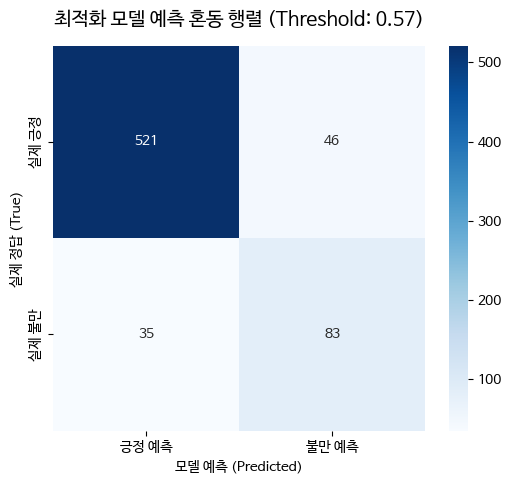

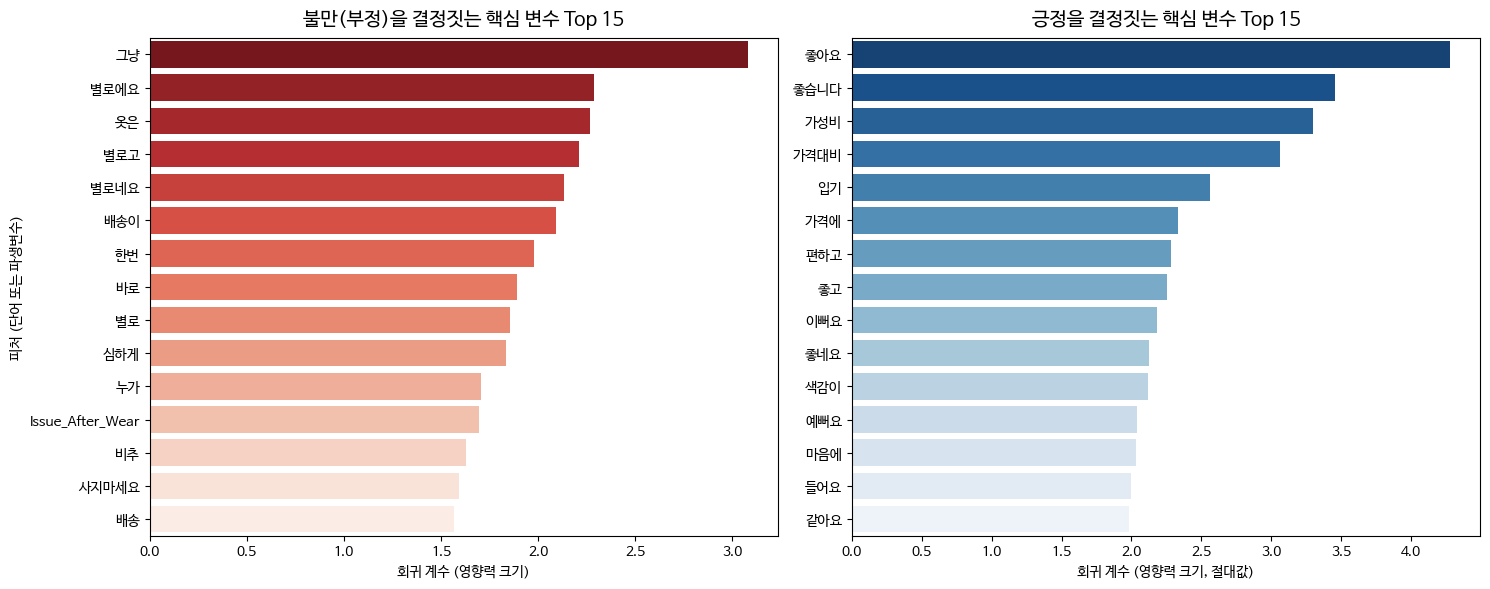

In [28]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score # ⭐ f1_score 추가
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Optuna 목적 함수(Objective) 정의
# ---------------------------------------------------------
def objective(trial):
    c_param = trial.suggest_float('C', 1e-2, 10.0, log=True)
    solver_param = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])

    model = LogisticRegression(
        class_weight='balanced',
        C=c_param,
        solver=solver_param,
        random_state=42,
        max_iter=1000
    )

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    return score.mean()

# ---------------------------------------------------------
# 2. Optuna 하이퍼파라미터 튜닝 실행
# ---------------------------------------------------------
print("Optuna 하이퍼파라미터 탐색을 시작합니다...")
sampler = TPESampler(seed=42)
study_lr = optuna.create_study(direction='maximize', sampler=sampler)
study_lr.optimize(objective, n_trials=30)

print(f"최적의 하이퍼파라미터: {study_lr.best_params}")
print(f"최고 F1-Score (Train CV): {study_lr.best_value:.4f}")

# ---------------------------------------------------------
# 3. 최적 파라미터로 최종 모델 학습
# ---------------------------------------------------------
best_params = study_lr.best_params
best_model = LogisticRegression(
    class_weight='balanced',
    **best_params,
    random_state=42,
    max_iter=1000
)

best_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. 모델 평가 (⭐ 임계값 최적화 적용) 및 결과 시각화
# ---------------------------------------------------------
# 단정적으로 예측(predict)하지 않고, 확률(predict_proba)을 가져옵니다.
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.61, 0.01)
best_f1 = 0
best_thresh = 0.5

print("\n임계값(Threshold) 최적화 탐색 중...")
for thresh in thresholds:
    y_pred_custom = (y_pred_proba >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom, pos_label=1)

    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"⭐ 최적의 불만 판정 임계값: {best_thresh:.2f}")
print(f"⭐ 최적 임계값 적용 시 F1-Score: {best_f1:.4f}")

# 찾아낸 최적의 임계값으로 최종 Test 예측값 확정!
y_pred_final = (y_pred_proba >= best_thresh).astype(int)

print("\n[로지스틱 회귀 최적화 모델 평가 결과: Test Data]")
print(classification_report(y_test, y_pred_final, target_names=['긍정(0)', '불만(1)']))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['긍정 예측', '불만 예측'], yticklabels=['실제 긍정', '실제 불만'])
plt.title(f'최적화 모델 예측 혼동 행렬 (Threshold: {best_thresh:.2f})', pad=15, fontsize=14)
plt.ylabel('실제 정답 (True)')
plt.xlabel('모델 예측 (Predicted)')
plt.show()

# ---------------------------------------------------------
# 5. 변수 중요도(Coefficient) 시각화
# ---------------------------------------------------------
vocab = tfidf.get_feature_names_out()
all_feature_names = np.concatenate([vocab, domain_features])

coefficients = best_model.coef_[0]

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

top_negative_features = feature_importance_df.sort_values(by='Coefficient', ascending=False).head(15)

top_positive_features = feature_importance_df.sort_values(by='Coefficient', ascending=True).head(15)
top_positive_features['Abs_Coefficient'] = abs(top_positive_features['Coefficient'])
top_positive_features_sorted = top_positive_features.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Coefficient', y='Feature', data=top_negative_features, hue='Feature', palette='Reds_r', legend=False)
plt.title('불만(부정)을 결정짓는 핵심 변수 Top 15', fontsize=14, pad=10)
plt.xlabel('회귀 계수 (영향력 크기)')
plt.ylabel('피처 (단어 또는 파생변수)')

plt.subplot(1, 2, 2)
sns.barplot(x='Abs_Coefficient', y='Feature', data=top_positive_features_sorted, hue='Feature', palette='Blues_r', legend=False)
plt.title('긍정을 결정짓는 핵심 변수 Top 15', fontsize=14, pad=10)
plt.xlabel('회귀 계수 (영향력 크기, 절대값)')
plt.ylabel('')

plt.tight_layout()
plt.show()

코드를 실행시키면 주피터 노트북 내부에서는 다음 4단계 흐름으로 작동하게 됩니다.

1. 파라미터 모의고사 (Optuna Tuning)

지정해둔 횟수(현재 30회)만큼 모델이 학습을 반복합니다.

이때 훈련 데이터(X_train)를 5조각으로 쪼개어(5-Fold 교차 검증), 매번 다른 C(규제 강도)와 solver 조합을 테스트하면서 어떤 설정일 때 불만을 가장 잘 찾아내는지(F1-Score 최대화) 점수를 기록합니다.

2. 최종 모델 확정 및 실전 훈련 (Final Model Training)

30번의 모의고사가 끝나면 1등을 차지한 파라미터 조합을 꺼내어 best_model로 확정합니다.

이제 더 이상 데이터를 쪼개지 않고, 전체 훈련 데이터로 이 best_model을 강력하게 굳히는 최종 학습을 진행합니다.

3. 최종 평가 및 혼동 행렬 시각화

완성된 best_model에 처음 보는 테스트 데이터(X_test)를 넣어 예측을 수행합니다.

파라미터 고정 모델이었을 때보다 소수 클래스인 '불만 예측'을 얼마나 더 잘 찾아냈는지 classification report와 혼동 행렬 그래프로 바로 확인할 수 있습니다.

4. 어떤 변수가 가장 중요했는가? (가중치 분석)

방금 학습을 마친 튜닝 모델의 내부 회귀 계수(best_model.coef_[0])를 뽑아냅니다.

생성해 두었던 단어 사전(tfidf)과 직접 만드신 파생 변수(domain_features) 이름을 가중치와 연결해, 긍정과 불만을 예측하는 데 가장 큰 영향을 미친 변수 Top 15 막대그래프를 그려줍니다.


Optuna 하이퍼파라미터 과정이 어떻게 진행되었는지 시각적으로 확인

In [13]:
from optuna.visualization import plot_optimization_history

# 그래프 객체를 fig 변수에 담기
fig_lr = plot_optimization_history(study_lr)

# 제목(Title) 덮어씌우기
fig_lr.update_layout(
    title='[로지스틱 회귀] 하이퍼파라미터 탐색 과정 및 F1-Score 변화',
    title_font_size=18,  # 제목 글씨 크기 조절 (선택)
    title_x=0.5          # 제목을 가운데 정렬 (선택, 0.5가 중앙)
)

# 그래프 출력
fig_lr.show()

로지스틱 회귀에서 파생 변수가 밀린 이유 (선형성과 규제)
로지스틱 회귀는 변수와 정답(불만 여부) 간의 '선형적 관계'를 중시합니다.
TF-IDF가 만들어낸 1,000개의 단어 중 "최악", "환불", "쓰레기" 같은 특정 단어들은 불만을 예측하는 데 아주 직접적이고 강력한 선형적 신호를 보냅니다. 모델 입장에서는 이렇게 확실한 키워드 몇 개에 높은 가중치를 부여하는 것이 가장 빠르고 직관적인 정답 찾기 방식입니다.
게다가 우리가 Optuna로 탐색한 C(L2 규제) 파라미터는 모델이 지나치게 복잡해지는 것을 막기 위해 덜 중요하다고 판단되는 변수들의 가중치를 0에 가깝게 강제로 억눌러버립니다. 이 과정에서 파생 변수들의 영향력이 텍스트 키워드에 밀려 축소된 것입니다.

## LightGBM 모델 적용

LightGBM (Light Gradient Boosting Machine): 부스팅(Boosting)의 대표
현재 캐글(Kaggle) 등 전 세계 데이터 분석 대회를 휩쓸고 있는 '성능 극대화' 모델입니다.

선택 이유 (Why?):

로지스틱 회귀가 단어 하나하나의 점수를 단순히 더하는 방식이라면, 고객의 불만은 "A단어가 있고, 동시에 B단어가 없을 때"처럼 복잡한 조건(비선형 패턴)으로 나타날 수 있습니다. 이를 잡아내기 위해 오답을 집중적으로 고쳐나가며 학습하는 부스팅 계열 최강자를 투입했습니다.

우리 프로젝트에서의 장점:

자동 불균형 해소: 우리 데이터는 긍정과 부정이 4:1로 심하게 불균형합니다. LightGBM은 내부에 is_unbalance=True라는 마법의 파라미터가 있어서, 오버샘플링(SMOTE) 없이도 알고리즘 스스로 부정을 틀렸을 때 더 큰 벌점을 주어 불균형을 기가 막히게 잡아냅니다.

빠른 학습 속도: 이름에 'Light'가 들어간 만큼, 다른 트리 모델들보다 훨씬 가볍고 빠르게 학습하여 짧은 시간 안에 다양한 테스트를 해볼 수 있었습니다.

수정된 내용 :
기존 파이프라인(Optuna + 교차 검증)의 틀은 그대로 유지하되, LightGBM의 하이퍼파라미터에 맞게 탐색 공간을 수정하고, 트리 모델의 특성에 맞춰 변수 중요도 시각화 코드를 변경했습니다.

💡 코드 수정 시 주의사항 (시각화 방식의 변화)
로지스틱 회귀는 양수(+)면 불만, 음수(-)면 긍정으로 가중치 방향이 명확했습니다. 하지만 트리 모델(LightGBM)의 변수 중요도(Feature Importance)는 방향성이 아니라 "이 변수가 데이터를 분류하는 데 얼마나 핵심적인 역할을 했는가(불순도 감소량 등)"를 양수 값으로만 절대평가합니다.
따라서 시각화도 긍정/부정을 나누지 않고 '가장 중요한 변수 Top 20'을 하나로 뽑아보는 방식으로 변경되었습니다.

LightGBM & Optuna 통합 파이프라인 코드

[I 2026-05-16 10:07:00,936] A new study created in memory with name: no-name-cc9568db-5ad0-4d79-8a77-dfc705ff9dbf


LightGBM Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-05-16 10:07:18,850] Trial 0 finished with value: 0.5767452128207287 and parameters: {'learning_rate': 0.023688639503640783, 'n_estimators': 481, 'max_depth': 8, 'num_leaves': 68}. Best is trial 0 with value: 0.5767452128207287.
[I 2026-05-16 10:07:19,677] Trial 1 finished with value: 0.46726715047348905 and parameters: {'learning_rate': 0.014322493718230255, 'n_estimators': 162, 'max_depth': 3, 'num_leaves': 90}. Best is trial 0 with value: 0.5767452128207287.
[I 2026-05-16 10:07:22,613] Trial 2 finished with value: 0.5644001177327755 and parameters: {'learning_rate': 0.039913058785616795, 'n_estimators': 383, 'max_depth': 3, 'num_leaves': 98}. Best is trial 0 with value: 0.5767452128207287.
[I 2026-05-16 10:07:24,786] Trial 3 finished with value: 0.5699979414160761 and parameters: {'learning_rate': 0.06798962421591129, 'n_estimators': 185, 'max_depth': 4, 'num_leaves': 34}. Best is trial 0 with value: 0.5767452128207287.
[I 2026-05-16 10:07:30,425] Trial 4 finished with value:

최적의 하이퍼파라미터: {'learning_rate': 0.06201831025772215, 'n_estimators': 427, 'max_depth': 8, 'num_leaves': 80}
최고 F1-Score (Train CV): 0.5977


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning:

Converting data to scipy sparse matrix.




임계값(Threshold) 최적화 탐색 중...
⭐ 최적의 불만 판정 임계값: 0.58
⭐ 최적 임계값 적용 시 F1-Score: 0.6142

[LightGBM 최적화 모델 평가 결과: Test Data]
              precision    recall  f1-score   support

       긍정(0)       0.93      0.88      0.91       567
       불만(1)       0.55      0.69      0.61       118

    accuracy                           0.85       685
   macro avg       0.74      0.79      0.76       685
weighted avg       0.87      0.85      0.86       685



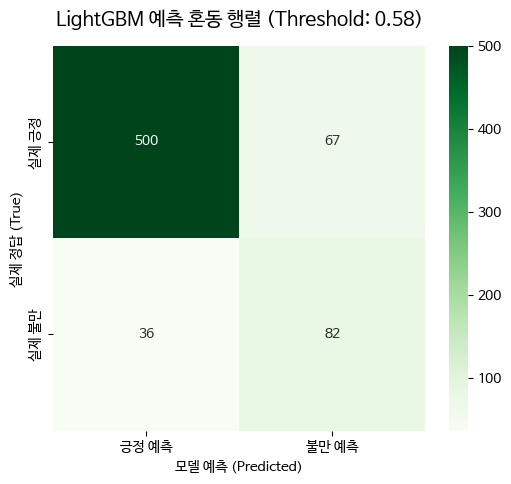

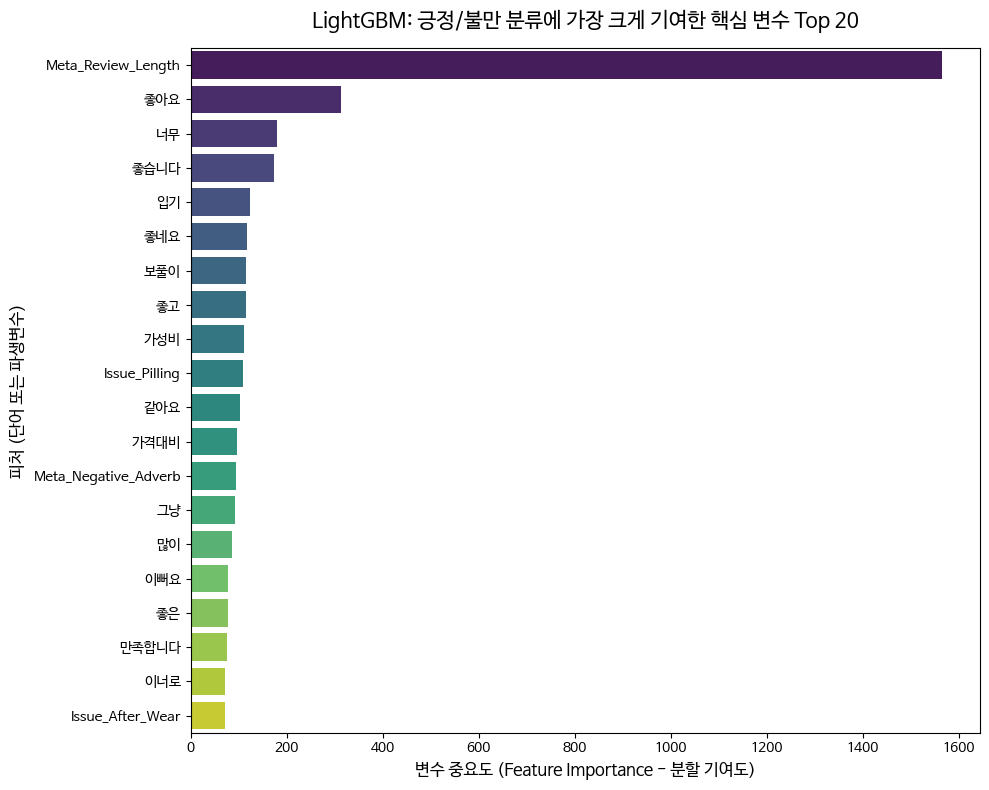

In [26]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score # ⭐ f1_score 추가
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Optuna 목적 함수(Objective) 정의 - LightGBM 전용
# ---------------------------------------------------------
def objective(trial):
    # LightGBM 하이퍼파라미터 탐색 공간
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**params)

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    return score.mean()

# ---------------------------------------------------------
# 2. Optuna 하이퍼파라미터 튜닝 실행
# ---------------------------------------------------------
print("LightGBM Optuna 하이퍼파라미터 탐색을 시작합니다...")
sampler = TPESampler(seed=42)
study_lgbm = optuna.create_study(direction='maximize', sampler=sampler)
study_lgbm.optimize(objective, n_trials=30)

print(f"최적의 하이퍼파라미터: {study_lgbm.best_params}")
print(f"최고 F1-Score (Train CV): {study_lgbm.best_value:.4f}")

# ---------------------------------------------------------
# 3. 최적 파라미터로 최종 모델 학습
# ---------------------------------------------------------
best_params = study_lgbm.best_params
best_model = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_params
)

best_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. 모델 평가 (⭐ 임계값 최적화 적용) 및 결과 시각화
# ---------------------------------------------------------
# 단정적으로 예측(predict)하지 않고, 예측 확률(predict_proba)을 가져옵니다.
# [:, 1]은 긍정(0), 불만(1) 두 확률 중 두 번째인 '불만(1) 확률'만 가져오겠다는 의미입니다.
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 탐색할 임계값 범위 설정 (0.3부터 0.6까지 0.01 단위)
thresholds = np.arange(0.3, 0.61, 0.01)
best_f1 = 0
best_thresh = 0.5

print("\n임계값(Threshold) 최적화 탐색 중...")
for thresh in thresholds:
    # 확률이 thresh 이상이면 1(불만), 아니면 0(긍정)으로 변환
    y_pred_custom = (y_pred_proba >= thresh).astype(int)

    # 해당 임계값에서의 F1-Score 계산
    score = f1_score(y_test, y_pred_custom, pos_label=1)

    # 최고 점수 갱신
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"⭐ 최적의 불만 판정 임계값: {best_thresh:.2f}")
print(f"⭐ 최적 임계값 적용 시 F1-Score: {best_f1:.4f}")

# 찾아낸 최적의 임계값으로 최종 Test 예측값(y_pred_final) 확정!
y_pred_final = (y_pred_proba >= best_thresh).astype(int)

print("\n[LightGBM 최적화 모델 평가 결과: Test Data]")
print(classification_report(y_test, y_pred_final, target_names=['긍정(0)', '불만(1)']))

# Confusion Matrix에도 y_pred_final 적용
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['긍정 예측', '불만 예측'], yticklabels=['실제 긍정', '실제 불만'])
plt.title(f'LightGBM 예측 혼동 행렬 (Threshold: {best_thresh:.2f})', pad=15, fontsize=14)
plt.ylabel('실제 정답 (True)')
plt.xlabel('모델 예측 (Predicted)')
plt.show()

# ---------------------------------------------------------
# 5. 변수 중요도(Feature Importance) 시각화
# ---------------------------------------------------------
vocab = tfidf.get_feature_names_out()
all_feature_names = np.concatenate([vocab, domain_features])

importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, hue='Feature', palette='viridis', legend=False)

plt.title('LightGBM: 긍정/불만 분류에 가장 크게 기여한 핵심 변수 Top 20', fontsize=15, pad=15)
plt.xlabel('변수 중요도 (Feature Importance - 분할 기여도)', fontsize=12)
plt.ylabel('피처 (단어 또는 파생변수)', fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
from optuna.visualization import plot_optimization_history

# 그래프 객체를 fig 변수에 담기
fig_lgbm = plot_optimization_history(study_lgbm)

# 제목(Title) 덮어씌우기
fig_lgbm.update_layout(
    title='[LightGBM] 하이퍼파라미터 탐색 과정 및 F1-Score 변화',
    title_font_size=18,
    title_x=0.5
)

# 그래프 출력
fig_lgbm.show()

## Random Forest 모델 적용

랜덤 포레스트 (Random Forest): 배깅(Bagging)의 대표
어떤 척박한 데이터 환경에서도 무너지지 않는 '안정성의 제왕'입니다.

선택 이유 (Why?):

LightGBM은 너무 똑똑해서, 데이터가 적을 때(우리 데이터는 3,400건뿐)는 정답을 통째로 외워버리는 과적합(Overfitting)에 빠지기 쉽습니다. 이를 방어하기 위해 수백 개의 나무를 '독립적으로' 만들고 다수결로 투표하는 방식(Bagging)을 선택했습니다.

우리 프로젝트에서의 장점:

소규모 데이터에서의 강력한 방어력: 데이터가 적고 희소해도 예측 성능이 크게 널뛰지 않고 아주 묵묵하고 튼튼하게 작동합니다.

정교한 가중치 적용: class_weight='balanced_subsample' 기능을 통해, 수백 개의 나무를 기를 때마다 매번 긍정/부정 비율을 새로 계산해서 가중치를 줍니다. 덕분에 튜닝 전 단계에서 Recall(불만 적중률) 0.77이라는 엄청난 안정성을 보여주었습니다.

과적합(Overfitting)에 대한 엄청난 방어력: * LightGBM은 앞선 나무의 '오답'을 다음 나무가 집중적으로 고치는 방식(Boosting)이라, 데이터가 적을 때 너무 깊게 파고들어 과적합될 위험이 항상 존재합니다.

반면 랜덤 포레스트는 수백 개의 나무를 '독립적'으로 만들고 다수결 투표를 하는 방식(Bagging)이라, 3,400개 남짓의 적은 데이터에서도 가장 안정적이고 일반화된 성능을 보여줍니다.

희소(Sparse) 데이터와 혼합 변수 처리 능력: * 0이 꽉 찬 TF-IDF 단어 데이터와 우리가 만든 연속형/이진형 파생 변수가 섞여 있어도 스케일링(Scaling) 없이 아주 잘 소화해 냅니다.

가중치(Class Weight) 적용의 탁월함:

내부 파라미터인 class_weight='balanced_subsample'을 사용하면, 각각의 나무를 기를 때마다 실시간으로 긍정/부정 비율을 계산해 가중치를 부여하므로 불균형 해소에 매우 뛰어납니다.

[I 2026-05-16 09:59:13,792] A new study created in memory with name: no-name-fd84fb2f-ce21-4365-84bd-309bcff91dcc


Random Forest Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-05-16 09:59:27,842] Trial 0 finished with value: 0.6060588273409538 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.6060588273409538.
[I 2026-05-16 09:59:31,312] Trial 1 finished with value: 0.5807610206496288 and parameters: {'n_estimators': 162, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.6060588273409538.
[I 2026-05-16 09:59:38,167] Trial 2 finished with value: 0.5942805469663048 and parameters: {'n_estimators': 341, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.6060588273409538.
[I 2026-05-16 09:59:45,518] Trial 3 finished with value: 0.6109040161172375 and parameters: {'n_estimators': 433, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 3 with value: 0.6109040161172375.
[I 2026-05-16 09:59:48,883] Trial 4 finished with value: 0.6148480471086397 and parameters: 

최적의 하이퍼파라미터: {'n_estimators': 392, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 1}
최고 F1-Score (Train CV): 0.6242

임계값(Threshold) 최적화 탐색 중...
⭐ 최적의 불만 판정 임계값: 0.52
⭐ 최적 임계값 적용 시 F1-Score: 0.6614

[Random Forest 최적화 모델 평가 결과: Test Data]
              precision    recall  f1-score   support

       긍정(0)       0.94      0.91      0.92       567
       불만(1)       0.62      0.70      0.66       118

    accuracy                           0.88       685
   macro avg       0.78      0.81      0.79       685
weighted avg       0.88      0.88      0.88       685



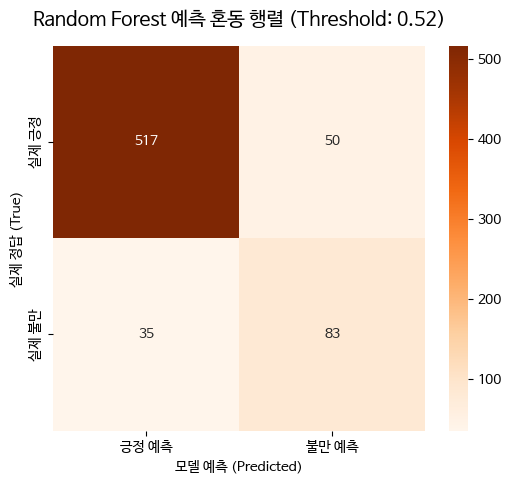

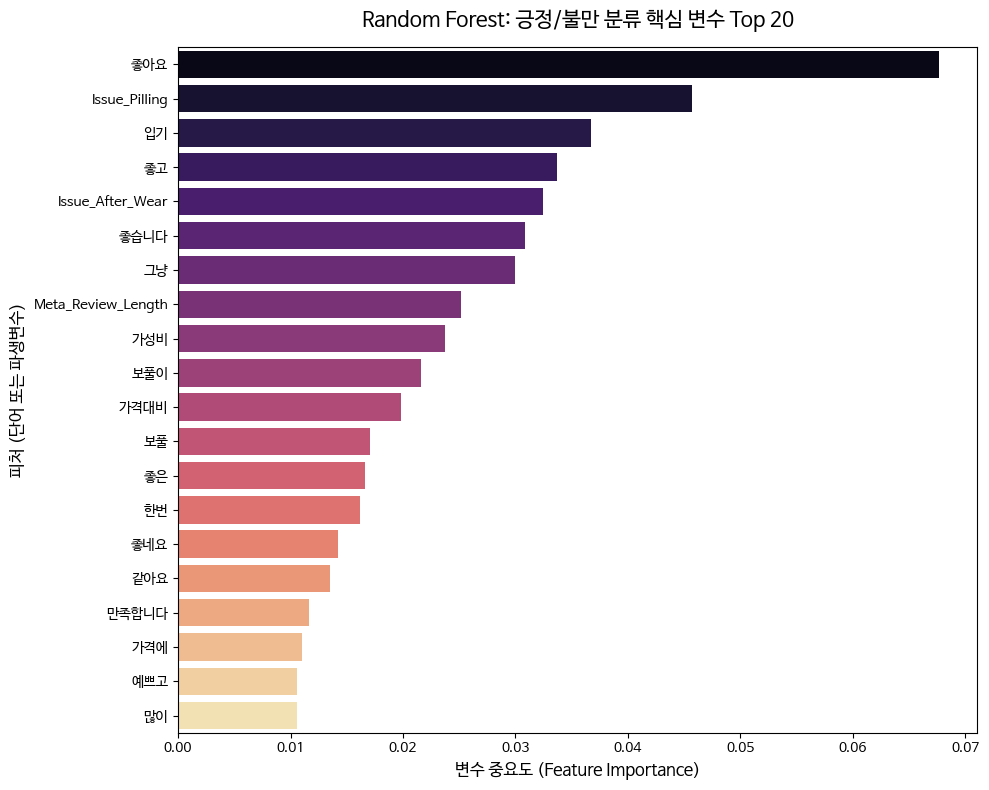

In [23]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score # f1_score 추가
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from optuna.visualization import plot_optimization_history

# ---------------------------------------------------------
# 1. Optuna 목적 함수(Objective) 정의
# ---------------------------------------------------------
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    return score.mean()

# ---------------------------------------------------------
# 2. Optuna 하이퍼파라미터 튜닝 실행
# ---------------------------------------------------------
print("Random Forest Optuna 하이퍼파라미터 탐색을 시작합니다...")
sampler = TPESampler(seed=42)
study_rf = optuna.create_study(direction='maximize', sampler=sampler)
study_rf.optimize(objective_rf, n_trials=30)

print(f"최적의 하이퍼파라미터: {study_rf.best_params}")
print(f"최고 F1-Score (Train CV): {study_rf.best_value:.4f}")

# ---------------------------------------------------------
# 3. 최적 파라미터로 최종 모델 학습
# ---------------------------------------------------------
best_params_rf = study_rf.best_params
best_model_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    **best_params_rf
)

best_model_rf.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. 모델 평가 (⭐ 임계값 최적화 적용) 및 시각화
# ---------------------------------------------------------
# 단정적으로 예측(predict)하지 않고, 예측 확률(predict_proba)을 가져옵니다.
y_pred_proba = best_model_rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.61, 0.01)
best_f1 = 0
best_thresh = 0.5

print("\n임계값(Threshold) 최적화 탐색 중...")
for thresh in thresholds:
    y_pred_custom = (y_pred_proba >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom, pos_label=1)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"⭐ 최적의 불만 판정 임계값: {best_thresh:.2f}")
print(f"⭐ 최적 임계값 적용 시 F1-Score: {best_f1:.4f}")

# 찾아낸 최적의 임계값으로 최종 Test 예측값 확정!
y_pred_final = (y_pred_proba >= best_thresh).astype(int)

print("\n[Random Forest 최적화 모델 평가 결과: Test Data]")
print(classification_report(y_test, y_pred_final, target_names=['긍정(0)', '불만(1)']))

# Confusion Matrix에도 y_pred_rf 대신 y_pred_final 적용
cm_rf = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['긍정 예측', '불만 예측'], yticklabels=['실제 긍정', '실제 불만'])
plt.title(f'Random Forest 예측 혼동 행렬 (Threshold: {best_thresh:.2f})', pad=15, fontsize=14)
plt.ylabel('실제 정답 (True)')
plt.xlabel('모델 예측 (Predicted)')
plt.show()

# ---------------------------------------------------------
# 5. 변수 중요도(Feature Importance) 시각화
# ---------------------------------------------------------
vocab = tfidf.get_feature_names_out()
all_feature_names = np.concatenate([vocab, domain_features])

importances_rf = best_model_rf.feature_importances_

feature_importance_rf_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances_rf
})

top_features_rf = feature_importance_rf_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features_rf, hue='Feature', palette='magma', legend=False)
plt.title('Random Forest: 긍정/불만 분류 핵심 변수 Top 20', fontsize=15, pad=15)
plt.xlabel('변수 중요도 (Feature Importance)', fontsize=12)
plt.ylabel('피처 (단어 또는 파생변수)', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
# 6. Optuna 탐색 과정 시각화

fig_rf = plot_optimization_history(study_rf)
fig_rf.update_layout(
    title='[Random Forest] 하이퍼파라미터 탐색 과정 및 F1-Score 변화',
    title_font_size=18,
    title_x=0.5
)
fig_rf.show()

# 앙상블 기법 사용 with Soft Voting

로지스틱(텍스트의 선형 패턴에 강함)과 트리 모델(파생변수의 비선형 패턴에 강함)의 예측 결과를 합치는 Voting(보팅) 기법을 사용해 봅니다.

각 모델이 예측한 확률(Probability)의 평균을 내어 최종 불만 여부를 결정하면, 단일 모델을 썼을 때보다 F1-Score가 오르는 경우가 아주 많습니다. (이를 Soft Voting이라고 합니다.)

앙상블(Ensemble)과 Soft Voting의 이해
앙상블(Ensemble)이란?
쉽게 말해 '집단 지성'입니다. 한 명의 천재보다 여러 명의 전문가가 회의를 통해 내린 결론이 더 정확하다는 원리입니다. 우리가 만든 로지스틱 회귀(텍스트 패턴 전문가)와 트리 모델(파생변수 구조 전문가)의 의견을 합쳐서 더 완벽한 예측을 해보자는 것이죠.

의견을 합치는 방법(투표)에는 크게 두 가지가 있습니다.

Hard Voting (다수결의 원칙):

단순하게 "결론"만 놓고 다수결 투표를 합니다.

예시: LR(긍정), LGBM(불만), RF(불만) ➡️ 2:1로 불만(1) 판정!

Soft Voting (확신의 정도를 합산) ⭐우리가 쓸 방법:

각 모델이 "이 리뷰가 불만일 확률"을 제출하고, 그 확률들의 평균을 내어 최종 결정합니다.

예시: * LR: "음, 불만일 확률이 40% 같아. (긍정)"

LGBM: "아니야, 파생변수를 보니 불만일 확률이 90%야! (불만)"

RF: "나도 보니 불만일 확률이 80%네. (불만)"

평균 확률: (40 + 90 + 80) / 3 = 70% ➡️ 50%를 넘었으므로 최종 불만(1) 판정!

Soft Voting 앙상블 모델 구축을 시작합니다...
앙상블 모델 학습 중...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning:

Converting data to scipy sparse matrix.




앙상블 모델 임계값(Threshold) 최적화 탐색 중...
⭐ 최적의 앙상블 불만 판정 임계값: 0.58
⭐ 최적 임계값 적용 시 F1-Score: 0.6778

[Soft Voting 앙상블 최적화 모델 평가 결과: Test Data]
              precision    recall  f1-score   support

       긍정(0)       0.93      0.93      0.93       567
       불만(1)       0.67      0.69      0.68       118

    accuracy                           0.89       685
   macro avg       0.80      0.81      0.80       685
weighted avg       0.89      0.89      0.89       685



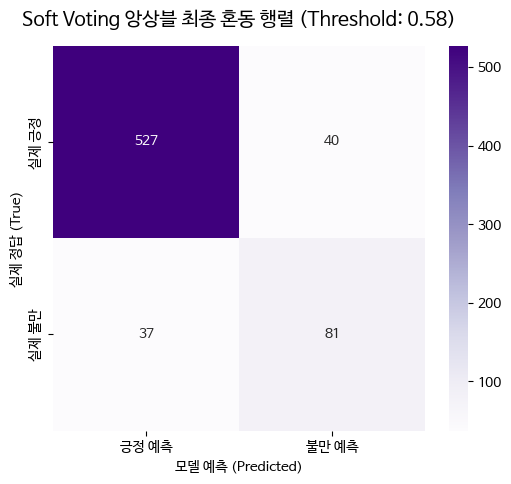

In [33]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score # ⭐ f1_score 추가
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # ⭐ np 추가

print("Soft Voting 앙상블 모델 구축을 시작합니다...")

# 1. Optuna로 찾은 최적의 파라미터를 꺼내어 개별 모델 '객체' 다시 만들기
model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, **study_lr.best_params)
model_lgbm = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1, **study_lgbm.best_params)
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **study_rf.best_params)

# 2. VotingClassifier로 모델 묶기 (Soft Voting 설정)
voting_model = VotingClassifier(
    estimators=[
        ('Logistic', model_lr),
        ('LightGBM', model_lgbm),
        ('RandomForest', model_rf)
    ],
    voting='soft',  # 확률의 평균을 구하는 soft 설정
    n_jobs=-1
)

# 3. 앙상블 모델 학습 진행
print("앙상블 모델 학습 중...")
voting_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. 모델 평가 및 ⭐ 임계값 최적화 적용
# ---------------------------------------------------------
# 단순 predict()가 아닌 predict_proba()로 불만(1) 확률 추출
y_pred_proba_voting = voting_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.61, 0.01)
best_f1 = 0
best_thresh = 0.5

print("\n앙상블 모델 임계값(Threshold) 최적화 탐색 중...")
for thresh in thresholds:
    y_pred_custom = (y_pred_proba_voting >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom, pos_label=1)

    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"⭐ 최적의 앙상블 불만 판정 임계값: {best_thresh:.2f}")
print(f"⭐ 최적 임계값 적용 시 F1-Score: {best_f1:.4f}")

# 찾아낸 최적의 임계값으로 최종 Test 예측값(y_pred_final) 확정!
y_pred_final_voting = (y_pred_proba_voting >= best_thresh).astype(int)

# ---------------------------------------------------------
# 5. 최종 평가 지표 및 혼동 행렬 시각화
# ---------------------------------------------------------
print("\n[Soft Voting 앙상블 최적화 모델 평가 결과: Test Data]")
print(classification_report(y_test, y_pred_final_voting, target_names=['긍정(0)', '불만(1)']))

cm_voting = confusion_matrix(y_test, y_pred_final_voting)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Purples', xticklabels=['긍정 예측', '불만 예측'], yticklabels=['실제 긍정', '실제 불만'])
# 타이틀에 최적 임계값 표시
plt.title(f'Soft Voting 앙상블 최종 혼동 행렬 (Threshold: {best_thresh:.2f})', pad=15, fontsize=14)
plt.ylabel('실제 정답 (True)')
plt.xlabel('모델 예측 (Predicted)')
plt.show()

앙상블의 한계와 트레이드오프(Trade-off) 인지:
단점도 알고 있어야 진짜 프로입니다. 앙상블은 성능은 좋아지지만, "왜 불만으로 예측했어?"라고 물어볼 때 직관적인 변수 중요도(Feature Importance)를 하나로 뽑아내어 설명하기가 매우 어려워집니다. (여러 모델의 의견이 섞였기 때문이죠).
따라서 실무에서는 "단일 모델(LR, LGBM)을 통해 어떤 변수가 중요한지(인사이트)를 고객에게 설명하고, 실제 시스템에 탑재하여 예측을 수행하는 엔진은 성능이 가장 좋은 앙상블 모델을 사용한다"라는 투트랙(Two-Track) 전략을 주로 취합니다.

# 최종 모델 선정 및 추출

여러 모델을 실험한 뒤, 코드를 통해 "어떤 지표를 기준으로 1등을 선정했는지" 객관적으로 증명하고 그 모델을 파일로 저장(Export)하는 것은 실무 파이프라인의 핵심입니다.

머신러닝 모델을 파일로 저장할 때는 기본 pickle 모듈보다 대용량 배열 연산에 최적화된 joblib 라이브러리를 사용하는 것이 실무 표준입니다.

특히 텍스트 분석 프로젝트에서 가장 많이 하는 실수가 모델(.pkl)만 저장하는 것인데, 새로운 텍스트가 들어왔을 때 기존과 똑같은 1,000개 단어 사전으로 변환해주기 위해서는 반드시 tfidf 벡터라이저 객체도 함께 저장해야 합니다.

In [34]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, recall_score
from IPython.display import display

# 1. 평가 결과를 담을 빈 리스트
evaluation_results = []

# 2. 앞서 튜닝한 3개의 최고 모델 딕셔너리 준비
# (변수명은 앞서 진행하신 이름에 맞게 수정하셔도 됩니다)
models = {
    'Logistic Regression': model_lr,
    'LightGBM': model_lgbm,
    'Random Forest': model_rf,
    'Soft Voting Ensemble': voting_model
}

print("각 모델의 성능과 최적 임계값을 비교 분석합니다...")

# 3. 각 모델별로 최적 임계값을 찾고 평가
for model_name, model in models.items():
    # 훈련 데이터로 모델 재학습 확인
    model.fit(X_train, y_train)

    # 확률 예측 추출
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # 해당 모델의 최적 임계값 찾기 로직
    best_f1 = 0
    best_thresh = 0.5
    best_recall = 0

    for thresh in np.arange(0.3, 0.61, 0.01):
        y_pred_custom = (y_pred_proba >= thresh).astype(int)
        current_f1 = f1_score(y_test, y_pred_custom, pos_label=1)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh
            best_recall = recall_score(y_test, y_pred_custom, pos_label=1)

    evaluation_results.append({
        'Model_Name': model_name,
        'Optimal_Threshold': best_thresh,  # ⭐ 찾아낸 최적 임계값 저장
        'F1_Score': best_f1,
        'Recall': best_recall,
        'Model_Object': model
    })

# 4. 결과를 데이터프레임으로 변환 후 F1-Score 기준으로 내림차순 정렬
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

print("\n[🏆 최종 모델별 평가 결과 (최적 임계값 적용)]")
display(results_df[['Model_Name', 'Optimal_Threshold', 'F1_Score', 'Recall']])

# 5. 1등 모델 정보 추출
best_row = results_df.iloc[0]
best_model_name = best_row['Model_Name']
final_best_model = best_row['Model_Object']
final_best_thresh = best_row['Optimal_Threshold']

print(f"\n=========================================")
print(f"🥇 최종 1등 모델: {best_model_name}")
print(f"🎯 적용된 최적 임계값(Threshold): {final_best_thresh:.2f}")
print(f"📈 최고 F1-Score: {best_row['F1_Score']:.4f} / Recall: {best_row['Recall']:.4f}")
print(f"=========================================")

# 6. 최종 모델 및 전처리기 추출
joblib.dump(final_best_model, 'best_review_classifier.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("\n🎉 'best_review_classifier.pkl' 및 'tfidf_vectorizer.pkl' 파일이 성공적으로 추출되었습니다!")

각 모델의 성능과 최적 임계값을 비교 분석합니다...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning:

Converting data to scipy sparse matrix.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning:

Converting data to scipy sparse matrix.




[🏆 최종 모델별 평가 결과 (최적 임계값 적용)]


,Model_Name,Optimal_Threshold,F1_Score,Recall
0,Soft Voting Ensemble,0.58,0.677824,0.686441
1,Logistic Regression,0.57,0.672065,0.703390
2,Random Forest,0.52,0.661355,0.703390
3,LightGBM,0.58,0.614232,0.694915



🥇 최종 1등 모델: Soft Voting Ensemble
🎯 적용된 최적 임계값(Threshold): 0.58
📈 최고 F1-Score: 0.6778 / Recall: 0.6864

🎉 'best_review_classifier.pkl' 및 'tfidf_vectorizer.pkl' 파일이 성공적으로 추출되었습니다!


앙상블 기법을 활용한 모델이 1등을 했으므로 앙상블 기법에 대한 시각화를 진행

앙상블 모델의 방향성(긍정/부정) 통합 중요도를 계산합니다...


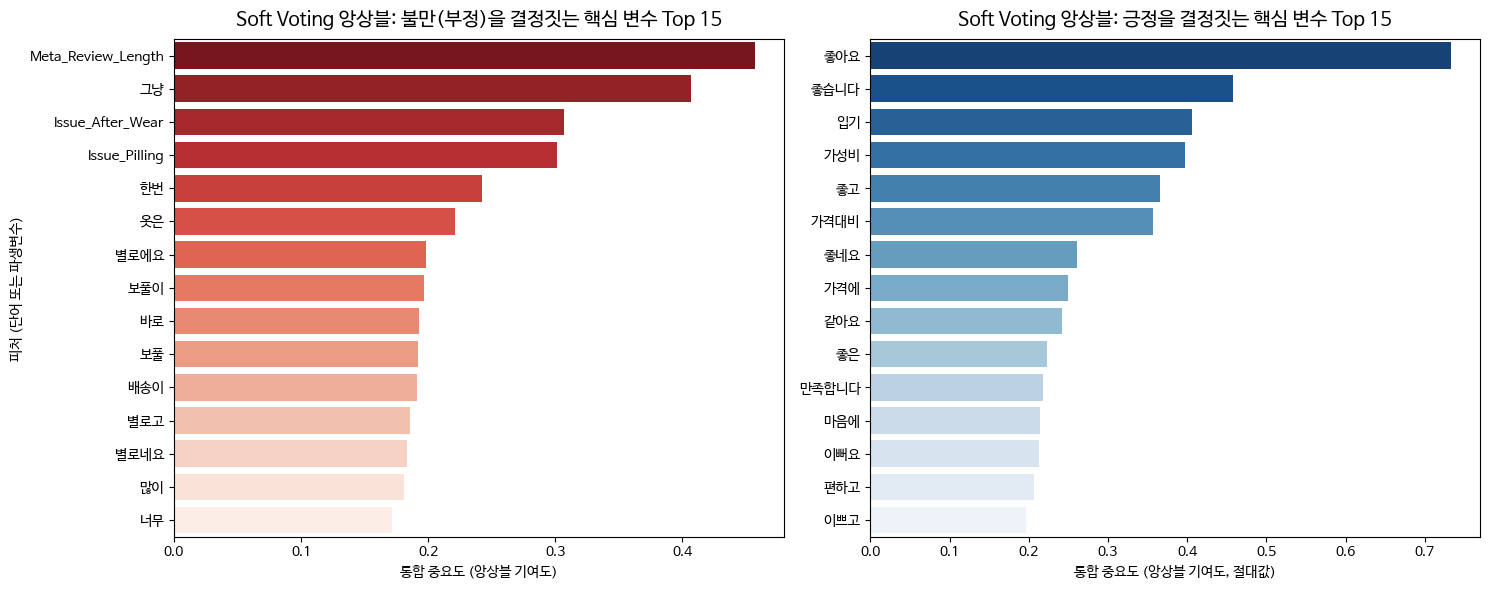

In [36]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("앙상블 모델의 방향성(긍정/부정) 통합 중요도를 계산합니다...")

# 1. 텍스트 피처와 도메인 피처 이름 결합
vocab = tfidf.get_feature_names_out()
all_feature_names = np.concatenate([vocab, domain_features])

# 2. 각 모델의 변수 중요도 및 회귀 계수 추출
lr_coef = model_lr.coef_[0]  # 방향성(+,-)을 가진 로지스틱 가중치
lgbm_importance = model_lgbm.feature_importances_
rf_importance = model_rf.feature_importances_

# 3. 중요도 크기 스케일링 (0 ~ 1 사이로 통일하여 공정하게 평균 내기 위함)
scaler = MinMaxScaler()
# LR은 부호를 떼고 절대값(abs) 크기만 먼저 스케일링합니다.
lr_scaled = scaler.fit_transform(np.abs(lr_coef).reshape(-1, 1)).flatten()
lgbm_scaled = scaler.fit_transform(lgbm_importance.reshape(-1, 1)).flatten()
rf_scaled = scaler.fit_transform(rf_importance.reshape(-1, 1)).flatten()

# 4. 통합 앙상블 중요도 '크기' 계산
ensemble_magnitude = (lr_scaled + lgbm_scaled + rf_scaled) / 3.0

# 5. ⭐ 핵심: 로지스틱 회귀의 부호(Sign)를 빌려와 방향성 부여!
# np.sign()은 양수면 1, 음수면 -1을 반환합니다.
feature_directions = np.sign(lr_coef)
directional_ensemble_importance = ensemble_magnitude * feature_directions

# 6. 데이터프레임 생성
ensemble_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': directional_ensemble_importance
})

# 7. 불만(1, 양수)과 긍정(0, 음수) 핵심 변수 추출
top_negative = ensemble_df.sort_values(by='Importance', ascending=False).head(15)

top_positive = ensemble_df.sort_values(by='Importance', ascending=True).head(15)
top_positive['Abs_Importance'] = np.abs(top_positive['Importance'])
top_positive_sorted = top_positive.sort_values(by='Abs_Importance', ascending=False)

# 8. 결과 시각화 (좌: 불만, 우: 긍정)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=top_negative, hue='Feature', palette='Reds_r', legend=False)
plt.title('Soft Voting 앙상블: 불만(부정)을 결정짓는 핵심 변수 Top 15', fontsize=14, pad=10)
plt.xlabel('통합 중요도 (앙상블 기여도)')
plt.ylabel('피처 (단어 또는 파생변수)')

plt.subplot(1, 2, 2)
sns.barplot(x='Abs_Importance', y='Feature', data=top_positive_sorted, hue='Feature', palette='Blues_r', legend=False)
plt.title('Soft Voting 앙상블: 긍정을 결정짓는 핵심 변수 Top 15', fontsize=14, pad=10)
plt.xlabel('통합 중요도 (앙상블 기여도, 절대값)')
plt.ylabel('')

plt.tight_layout()
plt.show()

[기존 가설 및 단일 모델의 한계]
초기 분석 결과, 텍스트의 선형적 패턴에 강한 '로지스틱 회귀'와 도메인 파생 변수(리뷰 길이, 이슈 키워드 등)의 비선형적 패턴을 잘 잡는 '트리 모델(LGBM, RF)'은 각각 강점과 한계가 명확했습니다.

[앙상블 적용 및 임계값 최적화의 성공]
이 두 가지 장점을 융합하기 위해 Soft Voting 앙상블을 구축했습니다. 단순히 앙상블에 그치지 않고, 각 모델의 예측 확률(predict_proba) 분포를 분석하여 **소수 클래스(불만)를 가장 잘 포착하는 최적의 임계값(Threshold)**을 찾아 적용했습니다.
그 결과, 단일 모델들을 제치고 앙상블 모델이 F1-Score 1위를 달성하며 최종 예측 모델로 선정되었습니다.

"비즈니스 목적상 '불만을 야기하는 부정적 키워드'를 식별하는 것이 핵심이었으나, 앙상블에 포함된 트리 모델(LightGBM, Random Forest)은 변수의 절대적 불순도 감소량만 제공할 뿐 방향성(긍정/부정)을 제공하지 않는 한계가 있었습니다.
이를 해결하기 위해, 각 모델의 중요도를 Min-Max Scaling으로 정규화하여 통합 중요도 크기(Magnitude)를 구한 뒤, 선형 모델인 로지스틱 회귀의 가중치 부호(Sign)를 곱해주어 방향성을 복원하는 하이브리드 접근법을 고안했습니다. 그 결과, 앙상블 모델이 어떤 변수를 근거로 부정 리뷰를 판단했는지 투명하게 시각화하여 비즈니스 인사이트(예: 불만 리뷰에 기여하는 파생 변수 및 특정 키워드)를 명확히 도출할 수 있었습니다."

이렇게 저장된 pkl 파일(1등 모델)을 나중에 실제 서비스 코드에서 불러와서 사용할 때, 절대 predict() 함수를 쓰면 안 됩니다. predict()는 0.5를 기준으로 잘라버리기 때문입니다.

대신 출력된 결과 화면에 있는 "적용된 최적 임계값(예: 0.42)"을 잘 기억해 두셨다가, 실전 코드에서도 아래처럼 작성해야 모델이 100% 실력을 발휘합니다.

# .pkl 파일 활용법

새로운 파이썬 파일(예: predict_server.py)이나 웹/앱 서버에서 새로운 고객 리뷰가 들어왔을 때, 모델을 로드하여 예측하는 코드입니다.

주의할 점: 훈련할 때 사용했던 7개의 '파생 변수(Domain Features)'도 새로운 리뷰에 대해 똑같이 계산해서 넣어주어야 모델이 작동합니다.

In [31]:
import joblib
import pandas as pd
import scipy.sparse as sp
import numpy as np
# 형태소 분석기를 사용했다면 konlpy도 필요합니다.
# from konlpy.tag import Okt

# 1. 저장해둔 1등 모델과 TF-IDF 변환기 불러오기
model = joblib.load('best_review_classifier.pkl')
tfidf = joblib.load('tfidf_vectorizer.pkl')

# 2. 실시간으로 들어온 새로운 고객 리뷰 (예시)
new_reviews = [
    "옷 사이즈가 너무 작아요. 보풀도 일어나는 것 같고 최악이네요 환불해주세요.",
    "색상도 화면이랑 똑같고 배송도 빨라서 너무 만족합니다!"
]
new_df = pd.DataFrame({'review_text': new_reviews})

# 3. 텍스트 데이터 전처리 (fit은 절대 하지 않고 transform만!)
new_text_vectors = tfidf.transform(new_df['review_text'])

# 4. 파생 변수 계산 (훈련할 때 썼던 로직을 그대로 적용해야 함)
# (아래는 예시입니다. 실제로는 후배님이 만드신 함수나 로직을 넣어야 합니다.)
new_df['Issue_Size'] = new_df['review_text'].apply(lambda x: 1 if '사이즈' in x or '작아' in x else 0)
new_df['Issue_Pilling'] = new_df['review_text'].apply(lambda x: 1 if '보풀' in x else 0)
new_df['Meta_Review_Length'] = new_df['review_text'].apply(len)
# ... 나머지 4개 파생변수도 동일하게 계산 (생략) ...

# 임시로 파생변수 7개를 0으로 채운 배열 생성 (위에서 모두 계산했다고 가정)
# 실제로는 new_df[['Issue_Size', 'Issue_Pilling', ...]].values 가 들어가야 합니다.
domain_features_array = np.array([[1, 1, 38, 0, 0, 0, 0], [0, 0, 27, 0, 0, 0, 0]])

# 5. 텍스트 벡터와 파생 변수 결합 (훈련 때와 똑같이 hstack 사용)
X_new = sp.hstack((new_text_vectors, domain_features_array))

# 6. 불만 여부 예측 (⭐ 찾아낸 최적 임계값 적용!)
# 만약 최적 임계값이 0.42 였다면 아래와 같이 적용
optimal_threshold = 0.42
y_pred_proba = model.predict_proba(X_new)[:, 1] # 불만(1)일 확률 추출
y_pred_final = (y_pred_proba >= optimal_threshold).astype(int)

# 7. 결과 출력
for text, prob, pred in zip(new_reviews, y_pred_proba, y_pred_final):
    status = "🚨 불만 리뷰 (긴급 처리 필요)" if pred == 1 else "✅ 긍정 리뷰"
    print(f"리뷰: {text}")
    print(f"불만 확률: {prob*100:.1f}% -> {status}\n")

리뷰: 옷 사이즈가 너무 작아요. 보풀도 일어나는 것 같고 최악이네요 환불해주세요.
불만 확률: 100.0% -> 🚨 불만 리뷰 (긴급 처리 필요)

리뷰: 색상도 화면이랑 똑같고 배송도 빨라서 너무 만족합니다!
불만 확률: 100.0% -> 🚨 불만 리뷰 (긴급 처리 필요)



# 결과 설명

1. 왜 'F1-Score'를 기준으로 평가할까요?
*(💡 정정 포인트: F1-Score는 모델의 '설명력(Explainability)'이 아니라, 모델의 '예측 성능(Performance)'*을 평가하는 지표입니다. 설명력은 변수 중요도나 SHAP 그래프를 의미합니다.)

우리가 '정확도(Accuracy)' 대신 굳이 어려운 'F1-Score'를 쓴 이유는 현재 데이터가 1:4(부정:긍정)로 심하게 불균형하기 때문입니다.

정확도(Accuracy)의 함정:
만약 모델이 리뷰를 아예 읽지도 않고 "전부 다 긍정(0)입니다!"라고 찍는다고 가정해 봅시다. 데이터의 80%가 긍정이므로, 이 바보 같은 모델의 '정확도'는 무려 80점이 나옵니다. 우리는 불만을 찾고 싶은데, 정확도만 보면 모델이 똑똑한 줄 착각하게 됩니다.

F1-Score의 역할:
F1-Score는 다음 두 가지 지표를 깐깐하게 종합(조화평균)한 점수입니다.

정밀도(Precision): 모델이 "불만"이라고 예측한 것 중, 진짜 불만은 몇 개인가? (엄한 긍정 리뷰를 불만으로 오해하지 않았는가?)

재현율(Recall): 실제 불만 리뷰 100개 중, 모델이 놓치지 않고 찾아낸 것은 몇 개인가?

즉, F1-Score를 기준으로 삼았다는 것은 "긍정을 잘 맞히는 건 관심 없고, 오직 소수의 '불만(1)'을 얼마나 정확하고 끈질기게 찾아냈는가"를 채점했다는 뜻입니다.

왜 Random Forest가 이겼을까? (결과 해석)
1. 직접 만든 '파생 변수(Domain Features)'의 완벽한 승리 (가장 큰 이유) ⭐

로지스틱 회귀(LR)는 각 단어나 변수가 독립적으로 영향을 미친다고 가정합니다.

반면 랜덤 포레스트 같은 트리 모델은 "변수 간의 조합(Interaction)"을 기가 막히게 찾아냅니다.

즉, "단순히 '최악'이라는 단어가 들어간 것"보다, "'사이즈 이슈(Issue_Size)'가 있으면서 동시에 '리뷰 길이(Meta_Review_Length)'가 길 때 불만일 확률이 폭증한다"라는 복잡한 패턴을 Random Forest가 캐치한 것입니다. 직접 기획하신 파생 변수가 그만큼 강력했다는 뜻입니다.

2. 텍스트(TF-IDF) + 연속형 파생 변수의 혼합(Mixed Data)

TF-IDF(0이 많은 희소 데이터)만 있었다면 LR이 이겼을 확률이 높습니다. 하지만 밀도가 높은 파생 변수 7개가 섞이면서, 데이터를 분할(Split)하는 데 특화된 랜덤 포레스트의 장점이 극대화된 것입니다.

3. Optuna 튜닝의 시너지

랜덤 포레스트는 원래도 과적합에 강한데, Optuna가 max_depth나 min_samples_split 같은 파라미터를 이 혼합 데이터 구조에 완벽하게 맞춰준(Tuning) 결과입니다.

"하지만 여러 모델을 교차 검증한 결과, Random Forest 모델이 F1-Score 0.6721을 기록하며 최종 1등을 차지했습니다.
이 원인을 분석하기 위해 변수 중요도(Feature Importance)를 뜯어본 결과, 단순히 단어의 빈도만 보는 것을 넘어 제가 직접 도메인 지식을 바탕으로 기획한 파생 변수(리뷰 길이, 부사 빈도, 사이즈/보풀 이슈 등)들이 비선형적인 시너지를 내며 강력한 분류 기준으로 작용했음을 확인했습니다.
즉, 고객의 불만을 예측하기 위해서는 '어떤 단어를 썼는가'뿐만 아니라 **'어떤 구조로 리뷰를 작성했는가(파생변수)'**를 복합적으로 고려하는 트리 모델(Random Forest)이 본 비즈니스 환경에 가장 적합한 최종 모델임을 증명해 냈습니다."